# REGRESIÓN LOGISTICA MULTICLASE PARA CLASIFICACIÓN DE FRIJOLES
## FUENTE : [KAGGLE](https://www.kaggle.com/datasets/sansuthi/dry-bean-dataset)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Dry_Bean.csv')
df.head(5)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


# EDA

In [3]:
df.dtypes.value_counts()

,count
float64,14
int64,2
object,1


In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
df.duplicated().sum()

np.int64(68)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df['Class'].unique()

array(['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'],
      dtype=object)

# UNDERSAMPLING

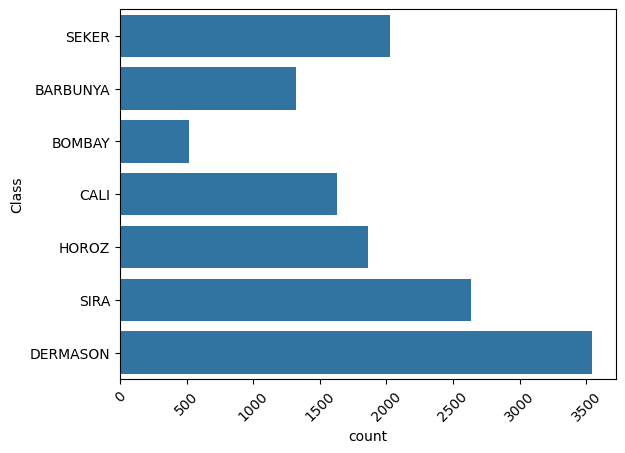

In [8]:
sns.countplot(df['Class'])
plt.xticks(rotation=45)
plt.show()

In [9]:
from imblearn.under_sampling import RandomUnderSampler
undersample = RandomUnderSampler(random_state=42)

In [10]:
X = df.drop('Class',axis=1)
y = df['Class']

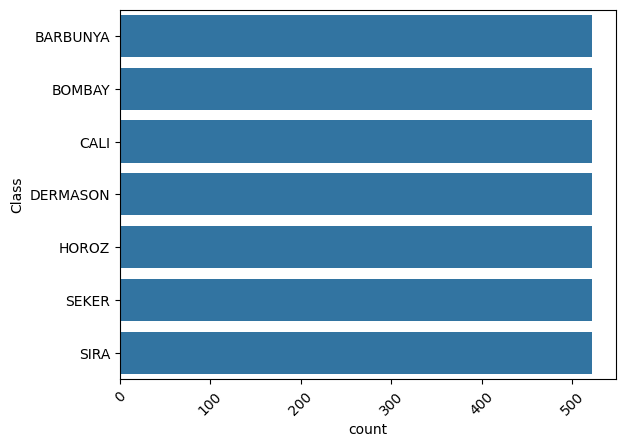

In [11]:
X_over,y_over = undersample.fit_resample(X,y)
sns.countplot(y_over)
plt.xticks(rotation=45)
plt.show()

# CODIFICACION DE VARIABLE DEPENDIENTE

In [12]:
y_over.replace(['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA'],[1,2,3,4,5,6,7],inplace=True)
list(np.unique(y_over))

/tmp/ipython-input-12-4064676665.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_over.replace(['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA'],[1,2,3,4,5,6,7],inplace=True)


[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7)]

# CORRELACIONES

In [14]:
df_corr = X_over
df_corr['Class'] = y_over
corr_matrix = df_corr.corr()
corr_class = corr_matrix['Class']
corr_class.sort_values(ascending=False)

,Class
Class,1.000000
ShapeFactor1,0.595998
ShapeFactor2,0.493776
roundness,0.436332
Solidity,0.320507
ShapeFactor4,0.202544
ShapeFactor3,0.177881
Compactness,0.160470
Extent,-0.084210
AspectRation,-0.100902


<Axes: >

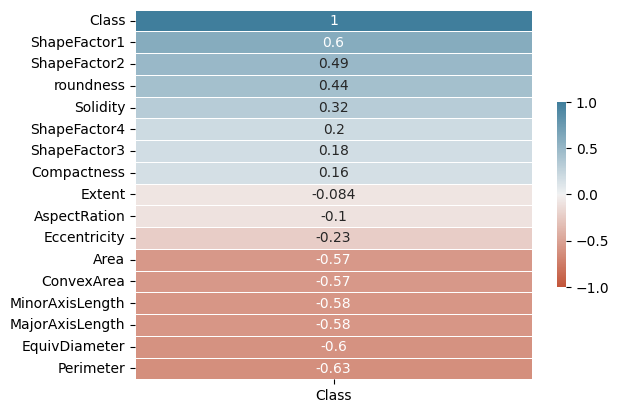

In [15]:
sns.heatmap(
    data=corr_class.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [16]:
corr_filtered = corr_class[corr_class > 0]
cols = corr_filtered.index.tolist()
cols

['Solidity',
 'roundness',
 'Compactness',
 'ShapeFactor1',
 'ShapeFactor2',
 'ShapeFactor3',
 'ShapeFactor4',
 'Class']

# ENTRENAMIENTO DEL MODELO DE CLASIFICACIÓN

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,ConfusionMatrixDisplay

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X_over,y_over,random_state=42,shuffle=True,test_size=0.2)

# ESTRATEGIAS PARA MANEJAR PROBLEMAS DE CLASIFICACIÓN MULTICLASE
* OVER(ONE VS REST) : esta estrategia entrena un clasificador binario por cada clase.
* multinomial : rata todas las clases al mismo tiempo en un solo modelo de clasificación multiclase.

# USANDO OVER

In [20]:
model_ovr = LogisticRegression(multi_class='ovr',solver='lbfgs',max_iter=500)
model_ovr.fit(X_train,y_train)
y_pred_ovr = model_ovr.predict(X_test)
print(f"Ovr Accuracy : {accuracy_score(y_test,y_pred_ovr)}")

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Ovr Accuracy : 0.9890560875512996


# MATRIZ DE CONFUSIÓN

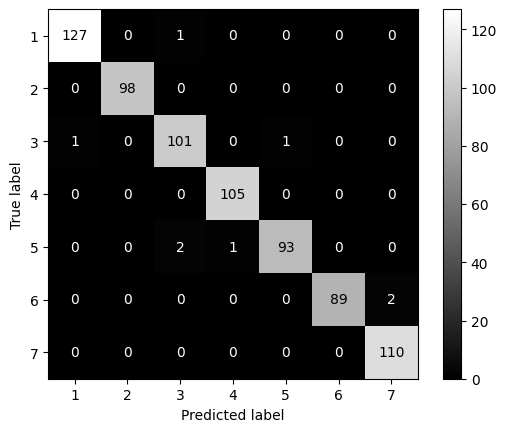

In [21]:
cm = confusion_matrix(y_test,y_pred_ovr,labels=model_ovr.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model_ovr.classes_)
disp.plot(cmap='gray')
plt.show()

# USANDO MULTINOMIAL

In [22]:
model_multinomial = LogisticRegression(multi_class='multinomial',solver='lbfgs',max_iter=500)
model_multinomial.fit(X_train,y_train)
y_pred_multinomial = model_multinomial.predict(X_test)
print(f"Ovr Multinomial : {accuracy_score(y_test,y_pred_multinomial)}")

Ovr Multinomial : 0.7756497948016415


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# MATRIZ DE CONFUSIÓN

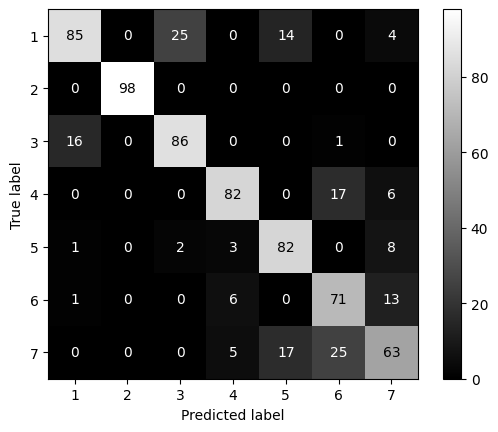

In [23]:
cm = confusion_matrix(y_test,y_pred_multinomial,labels=model_multinomial.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model_multinomial.classes_)
disp.plot(cmap='gray')
plt.show()